# Training a neural network to transform continuous into discrete observations for a `pymdp` Agent

With `pymdp`'s JAX backend, it's straightforward to combine differentiable modules with `pymdp`'s active inference processes. We can use tools from `JAX`'s rich neural network ecosystem (`flax`, `optax`, `equinox`, `haiku`, to name a few) and combine them with active inference agents in creative ways.

In this tutorial, we use a simple neural network to embed continuous observations into an `pymdp` agent's observation space; we can train the encoder end-to-end, enabled by JAX's native compatibility with autodifferentiable programs and `pymdp`'s autodifferentiable `Agent` and `Agent` methods.

For this simple demo, we fix a discrete generative model (fixed/known `A`, `B`) and train a simple MLP (in `equinox`) to maps continuous observations into categorical classes, which can be ingested as observations by the `pymdp` Agent. Because the inference path is differentiable, gradients from a variational objective can flow back through `Agent`-level methods (like `Agent.infer_states`) into encoder parameters.



## 1. Imports

We use JAX/Equinox for pymdp and building our neural network, `pymdp.Agent` for active inference, and Matplotlib for diagnostics and animations.



In [1]:
import time
from itertools import permutations

import equinox as eqx
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import jax.tree_util as jtu
import matplotlib.pyplot as plt
from matplotlib import animation

from pymdp.agent import Agent
plt.rcParams['animation.html'] = 'jshtml'


## 2. Setup

We define a 5-state line world with local controls (`back`, `stay`, `forward`) and set some training hyperparameters.

In [2]:
# Reproducibility
GLOBAL_KEY = jr.PRNGKey(1)

# Problem size
K = 5
O = K
U = 3
BACK_ACTION = 0
STAY_ACTION = 1
FORWARD_ACTION = 2
D = 2
T = 6
POLICY_LEN = 4

# Data and training settings
N_TRAIN = 640
N_VAL = 320
BATCH_SIZE = 16
TRAIN_STEPS = 200
CHECKPOINT_EVERY = 20
LR = 1e-3

# Encoder architecture
ENCODER_WIDTH = 256
ENCODER_DEPTH = 3
LOGIT_TEMPERATURE = 0.15

# Loss weights
TEMPORAL_CONSISTENCY_WEIGHT = 8.0

# Numerical stability
EPS_A = 1e-4
EPS = 1e-8

# Observation model / dynamics assumptions
TRANSITION_NOISE = 0.1

# Continuous emissions: one Gaussian mean per discrete state
GAUSSIAN_MEANS = jnp.array([
    [ 0.0,  3.2],
    [ 3.0,  1.0],
    [ 1.9, -2.6],
    [-1.9, -2.6],
    [-3.0,  1.0],
])
GAUSSIAN_SCALE = 1.0

TARGET_STATE = K - 1
START_STATE = 0
ROLLOUT_HORIZON = 8

## 3. Build the Fixed Discrete Agent

The agent's generative model is fixed throughout training:

- `A`: epsilon-smoothed identity (observation categories aligned with hidden states)
- `B`: line dynamics with action-conditioned transitions
- `C`: preference for the terminal state
- `D`: uniform prior over initial hidden states

Only the front-end encoder is optimized.



In [3]:
def make_eps_identity_A(num_states: int, eps: float) -> jnp.ndarray:
    eye = jnp.eye(num_states)
    off = (1.0 - eye) * (eps / (num_states - 1))
    return (1.0 - eps) * eye + off


def make_B_line(num_states: int, num_controls: int, transition_noise: float) -> jnp.ndarray:

    B_det = jnp.zeros((num_states, num_states, num_controls))

    for s in range(num_states):
        back_next = max(s - 1, 0)
        stay_next = s
        forward_next = min(s + 1, num_states - 1)

        B_det = B_det.at[back_next, s, BACK_ACTION].set(1.0)
        B_det = B_det.at[stay_next, s, STAY_ACTION].set(1.0)
        B_det = B_det.at[forward_next, s, FORWARD_ACTION].set(1.0)

    B = (1.0 - transition_noise) * B_det + transition_noise * (jnp.ones_like(B_det) / num_states)
    B = B / jnp.sum(B, axis=0, keepdims=True)
    return B


A_FIXED_SINGLE = make_eps_identity_A(K, EPS_A)
B_TRUE = make_B_line(K, U, TRANSITION_NOISE)


def build_agent(batch_size: int) -> Agent:
    A = [jnp.broadcast_to(A_FIXED_SINGLE, (batch_size, O, K))]
    B = [jnp.broadcast_to(B_TRUE, (batch_size, K, K, U))]

    C_single = jnp.zeros((O,)).at[TARGET_STATE].set(8.0)
    C = [jnp.broadcast_to(C_single, (batch_size, O))]

    D_single = jnp.ones((K,)) / K
    D = [jnp.broadcast_to(D_single, (batch_size, K))]

    return Agent(
        A=A,
        B=B,
        C=C,
        D=D,
        A_dependencies=[[0]],
        B_dependencies=[[0]],
        num_controls=[U],
        batch_size=batch_size,
        policy_len=POLICY_LEN,
        categorical_obs=True,
        inference_algo='fpi',
        num_iter=1,
        action_selection='deterministic',
        sampling_mode='full',
        use_utility=True,
        use_states_info_gain=True, # although it doesn't matter here
        use_param_info_gain=False,
        learn_A=False,
        learn_B=False,
    )


print('A fixed diagonal:', jnp.round(jnp.diag(A_FIXED_SINGLE), 3).tolist())
print('Local transitions by state:')
for s in range(K):
    to_back = int(jnp.argmax(B_TRUE[:, s, BACK_ACTION]))
    to_stay = int(jnp.argmax(B_TRUE[:, s, STAY_ACTION]))
    to_fwd = int(jnp.argmax(B_TRUE[:, s, FORWARD_ACTION]))
    print(f'  state {s}: back -> {to_back}, stay -> {to_stay}, forward -> {to_fwd}')

A fixed diagonal: [1.0, 1.0, 1.0, 1.0, 1.0]
Local transitions by state:
  state 0: back -> 0, stay -> 0, forward -> 1
  state 1: back -> 0, stay -> 1, forward -> 2
  state 2: back -> 1, stay -> 2, forward -> 3
  state 3: back -> 2, stay -> 3, forward -> 4
  state 4: back -> 3, stay -> 4, forward -> 4


## 4. Generate Offline Continuous Trajectories

We simulate offline sequences with balanced state coverage and random actions.

Each discrete state emits a 2D Gaussian sample, giving paired trajectories of:

- continuous observations `x_t`
- latent states `s_t` (for evaluation only)
- actions `a_t` (used to propagate empirical priors during training)



In [4]:
def sample_categorical_batch(key: jnp.ndarray, probs: jnp.ndarray) -> jnp.ndarray:
    keys = jr.split(key, probs.shape[0])
    return jax.vmap(lambda k, p: jr.categorical(k, jnp.log(jnp.clip(p, a_min=EPS))))(keys, probs).astype(jnp.int32)


def sample_balanced_initial_states(key: jnp.ndarray, num_sequences: int) -> jnp.ndarray:
    reps = (num_sequences + K - 1) // K
    base = jnp.tile(jnp.arange(K, dtype=jnp.int32), reps)[:num_sequences]
    perm = jr.permutation(key, num_sequences)
    return base[perm]


def sample_uniform_actions(key: jnp.ndarray, num_sequences: int) -> jnp.ndarray:
    return jr.randint(key, shape=(num_sequences,), minval=0, maxval=U).astype(jnp.int32)


def simulate_gaussian_sequences(
    key: jnp.ndarray,
    num_sequences: int,
    seq_len: int,
    means: jnp.ndarray,
    scale: float,
):
    key_init, key_loop = jr.split(key, 2)
    s_t = sample_balanced_initial_states(key_init, num_sequences)

    xs, ss, acts = [], [], []

    for _ in range(seq_len):
        key_loop, key_action, key_obs, key_trans = jr.split(key_loop, 4)

        a_t = sample_uniform_actions(key_action, num_sequences)
        x_t = means[s_t] + scale * jr.normal(key_obs, (num_sequences, D))

        xs.append(x_t)
        ss.append(s_t)
        acts.append(a_t[:, None])

        next_probs = jax.vmap(lambda s, a: B_TRUE[:, s, a])(s_t, a_t)
        s_t = sample_categorical_batch(key_trans, next_probs)

    return {
        'x_seq': jnp.stack(xs, axis=1),
        's_seq': jnp.stack(ss, axis=1),
        'a_seq': jnp.stack(acts, axis=1),
    }


def state_props(data):
    counts = jnp.bincount(data['s_seq'].reshape(-1), length=K)
    return counts / jnp.sum(counts)


def action_props(data):
    counts = jnp.bincount(data['a_seq'][..., 0].reshape(-1), length=U)
    return counts / jnp.sum(counts)


GLOBAL_KEY, key_train, key_val, key_encoder = jr.split(GLOBAL_KEY, 4)
train_data = simulate_gaussian_sequences(key_train, N_TRAIN, T, GAUSSIAN_MEANS, GAUSSIAN_SCALE)
val_data = simulate_gaussian_sequences(key_val, N_VAL, T, GAUSSIAN_MEANS, GAUSSIAN_SCALE)

print('train x_seq:', train_data['x_seq'].shape)
print('train s_seq:', train_data['s_seq'].shape)
print('train a_seq:', train_data['a_seq'].shape)

print('train state proportions:', jnp.round(state_props(train_data), 3))
print('val state proportions:', jnp.round(state_props(val_data), 3))
print('train action proportions:', jnp.round(action_props(train_data), 3))
print('val action proportions:', jnp.round(action_props(val_data), 3))

train x_seq: (640, 6, 2)
train s_seq: (640, 6)
train a_seq: (640, 6, 1)
train state proportions: [0.21300001 0.201      0.194      0.19600001 0.19500001]
val state proportions: [0.21100001 0.20300001 0.20500001 0.19500001 0.186     ]
train action proportions: [0.34600002 0.324      0.33      ]
val action proportions: [0.356      0.312      0.33100003]


## 5. Define the Differentiable Front-End

The encoder is an Equinox MLP:

`x_t -> logits_o_t -> softmax -> o_hat_t`

`o_hat_t` is passed directly to `Agent.infer_states` as a categorical observation distribution.



In [5]:
class ObservationEncoder(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, key: jnp.ndarray, width: int = ENCODER_WIDTH, depth: int = ENCODER_DEPTH):
        self.mlp = eqx.nn.MLP(
            in_size=D,
            out_size=O,
            width_size=width,
            depth=depth,
            activation=jnn.tanh,
            final_activation=lambda x: x,
            key=key,
        )

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        return self.mlp(x)


class FrontendModel(eqx.Module):
    encoder: ObservationEncoder

    def __init__(self, key_encoder: jnp.ndarray):
        self.encoder = ObservationEncoder(key_encoder)


def model_obs_categorical(model: FrontendModel, x_t: jnp.ndarray):
    logits = jax.vmap(model.encoder)(x_t) / LOGIT_TEMPERATURE
    probs = jnn.softmax(logits, axis=-1)
    probs = jnp.clip(probs, a_min=EPS)
    probs = probs / probs.sum(axis=-1, keepdims=True)
    return [probs]


key_encoder, _ = jr.split(key_encoder)
model_init = FrontendModel(key_encoder)
print('encoder initialized')

encoder initialized


## 6. Define the Training Objective

We optimize a label-free objective composed of:

- state-level variational free energy (VFE) (ignores complexity / KL terms related to parameters A, B, D)
- temporal observation consistency between `o_hat_{t+1}` and dynamics-predicted next-state beliefs projected through `A`

Objective:

`loss = mean_t VFE_t + lambda_temp * KL_temporal`

This is the key mechanism that encourages the encoder to partition continuous space into discrete categories compatible with the fixed agent model.



In [6]:
def compute_vfe_state(qs_t, prior_t, obs_cat_t, A_current):
    q = jnp.clip(qs_t[0], a_min=EPS)
    p = jnp.clip(prior_t[0], a_min=EPS)

    kl = jnp.sum(q * (jnp.log(q) - jnp.log(p)), axis=-1)

    o = jnp.clip(obs_cat_t[0], a_min=EPS)
    logA = jnp.log(jnp.clip(A_current[0], a_min=EPS))
    loglik_s = jnp.einsum('bo,bok->bk', o, logA)
    accuracy = jnp.sum(q * loglik_s, axis=-1)

    return kl - accuracy


def temporal_obs_consistency_kl(obs_seq: jnp.ndarray, pred_next_state_seq: jnp.ndarray):
    if obs_seq.shape[1] <= 1:
        return jnp.array(0.0)

    pred_obs_next = jnp.einsum('btk,ok->bto', pred_next_state_seq, A_FIXED_SINGLE)
    pred_obs_next = jnp.clip(pred_obs_next, a_min=EPS)
    pred_obs_next = pred_obs_next / pred_obs_next.sum(axis=-1, keepdims=True)

    obs_next = jnp.clip(obs_seq[:, 1:, :], a_min=EPS)
    kl = jnp.sum(obs_next * (jnp.log(obs_next) - jnp.log(pred_obs_next)), axis=-1)
    return jnp.mean(kl)


def sequence_loss_terms(model: FrontendModel, batch: dict, agent: Agent):
    batch_size = batch['x_seq'].shape[0]

    prior = agent.D
    total_vfe = jnp.array(0.0)
    obs_seq = []
    pred_next_state = []

    n_steps = batch['x_seq'].shape[1]

    for t in range(n_steps):
        x_t = batch['x_seq'][:, t, :]
        obs_t = model_obs_categorical(model, x_t)
        obs_seq.append(obs_t[0])

        qs_hist_t = agent.infer_states(obs_t, empirical_prior=prior)
        qs_t = [q[:, -1, :] for q in qs_hist_t]

        F_t = compute_vfe_state(qs_t, prior, obs_t, agent.A)
        total_vfe = total_vfe + jnp.mean(F_t)

        a_t = batch['a_seq'][:, t, :]
        prior_next = agent.update_empirical_prior(a_t, qs_hist_t)
        if t < n_steps - 1:
            pred_next_state.append(prior_next[0])
        prior = prior_next

    obs_seq = jnp.stack(obs_seq, axis=1)
    pred_next_state = jnp.stack(pred_next_state, axis=1) if n_steps > 1 else jnp.zeros((batch_size, 0, K))

    mean_vfe = total_vfe / n_steps
    temporal_kl = temporal_obs_consistency_kl(obs_seq, pred_next_state)
    total = mean_vfe + TEMPORAL_CONSISTENCY_WEIGHT * temporal_kl

    return total, mean_vfe, temporal_kl, obs_seq


def sequence_objective(model: FrontendModel, batch: dict, agent: Agent):
    total, _, _, _ = sequence_loss_terms(model, batch, agent)
    return total


def sample_batch(key: jnp.ndarray, data: dict, batch_size: int):
    idx = jr.choice(key, data['x_seq'].shape[0], shape=(batch_size,), replace=False)
    return {k: v[idx] for k, v in data.items()}


def best_aligned_accuracy(true_labels: jnp.ndarray, pred_labels: jnp.ndarray):
    t = true_labels.reshape(-1).astype(jnp.int32)
    p = pred_labels.reshape(-1).astype(jnp.int32)

    best_acc = -1.0
    best_perm = tuple(range(K))
    for perm in permutations(range(K)):
        p_mapped = jnp.array(perm)[p]
        acc = float(jnp.mean(p_mapped == t))
        if acc > best_acc:
            best_acc = acc
            best_perm = perm
    return best_acc, best_perm


def infer_qs_sequence(model: FrontendModel, batch: dict, agent: Agent):
    prior = agent.D
    qs_all = []

    for t in range(batch['x_seq'].shape[1]):
        x_t = batch['x_seq'][:, t, :]
        obs_t = model_obs_categorical(model, x_t)
        qs_hist_t = agent.infer_states(obs_t, empirical_prior=prior)
        qs_t = qs_hist_t[0][:, -1, :]
        qs_all.append(qs_t)

        a_t = batch['a_seq'][:, t, :]
        prior = agent.update_empirical_prior(a_t, qs_hist_t)

    return jnp.stack(qs_all, axis=1)


def predict_obs_idx(model: FrontendModel, x_points: jnp.ndarray):
    logits = jax.vmap(model.encoder)(x_points) / LOGIT_TEMPERATURE
    return jnp.argmax(logits, axis=-1)

## 7. Train the Encoder

We train with minibatches sampled from offline trajectories.

At each timestep in a sequence, the notebook:

1. encodes `x_t` to `o_hat_t`
2. runs `infer_states(o_hat_t, prior_t)`
3. accumulates VFE
4. updates prior using observed `a_t`
5. accumulates temporal consistency across steps

Gradients are computed with `eqx.filter_value_and_grad` and applied directly to encoder parameters.



In [7]:
train_agent = build_agent(BATCH_SIZE)

@eqx.filter_jit
def train_step(model: FrontendModel, batch: dict):
    loss, grads = eqx.filter_value_and_grad(sequence_objective)(model, batch, train_agent)
    updates = jtu.tree_map(lambda g: -LR * g if g is not None else None, grads)
    model = eqx.apply_updates(model, updates)
    return model, loss, grads


def evaluate_model(model_eval: FrontendModel, batch: dict, agent: Agent):
    qs_seq = infer_qs_sequence(model_eval, batch, agent)
    pred_states = jnp.argmax(qs_seq, axis=-1)
    raw_acc = float(jnp.mean(pred_states == batch['s_seq']))
    aligned_acc, best_perm = best_aligned_accuracy(batch['s_seq'], pred_states)

    total, mean_vfe, temporal_kl, _ = sequence_loss_terms(model_eval, batch, agent)

    return {
        'raw_acc': raw_acc,
        'aligned_acc': float(aligned_acc),
        'best_perm': best_perm,
        'total': float(total),
        'vfe': float(mean_vfe),
        'temporal_kl': float(temporal_kl),
        'pred_states': pred_states,
    }


GLOBAL_KEY, key_probe = jr.split(GLOBAL_KEY)
probe_batch = sample_batch(key_probe, train_data, BATCH_SIZE)
probe_loss, probe_grads = eqx.filter_value_and_grad(sequence_objective)(model_init, probe_batch, train_agent)
print('initial objective:', float(probe_loss))

model = model_init
train_total_curve = []
train_vfe_curve = []
train_temp_curve = []
val_total_curve = []
val_vfe_curve = []
val_temp_curve = []
curve_steps = []

start = time.time()
for step in range(TRAIN_STEPS):
    GLOBAL_KEY, key_batch, key_val = jr.split(GLOBAL_KEY, 3)
    train_batch = sample_batch(key_batch, train_data, BATCH_SIZE)
    model, loss, grads = train_step(model, train_batch)

    if (step % CHECKPOINT_EVERY == 0) or (step == TRAIN_STEPS - 1):
        val_batch = sample_batch(key_val, val_data, BATCH_SIZE)

        train_metrics = evaluate_model(model, train_batch, train_agent)
        val_metrics = evaluate_model(model, val_batch, train_agent)

        train_total_curve.append(train_metrics['total'])
        train_vfe_curve.append(train_metrics['vfe'])
        train_temp_curve.append(train_metrics['temporal_kl'])
        val_total_curve.append(val_metrics['total'])
        val_vfe_curve.append(val_metrics['vfe'])
        val_temp_curve.append(val_metrics['temporal_kl'])
        curve_steps.append(step)

elapsed = time.time() - start
print(f'training finished in {elapsed:.2f}s')
print('final train total/vfe/temp:', train_total_curve[-1], train_vfe_curve[-1], train_temp_curve[-1])
print('final val total/vfe/temp:', val_total_curve[-1], val_vfe_curve[-1], val_temp_curve[-1])

/var/folders/_f/1qqqnkyd5k5g2b1pgfwzzrqm0000gn/T/ipykernel_5016/1731807479.py:39: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


initial objective: 15.04537582397461
training finished in 4.16s
final train total/vfe/temp: 6.0631303787231445 1.2384618520736694 0.6030835509300232
final val total/vfe/temp: 4.517773151397705 1.1381117105484009 0.42245766520500183


## 8. Evaluate Representation Quality

We evaluate both:

- encoder-level discrete assignments (`argmax` over encoder logits)
- inferred-state assignments (`argmax` over `q(s_t)`)

To account for permutation symmetry, accuracy is reported after best label alignment.



/var/folders/_f/1qqqnkyd5k5g2b1pgfwzzrqm0000gn/T/ipykernel_5016/1731807479.py:39: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


Encoder aligned acc (pre/post): 0.5838541984558105 0.9515625238418579
Inferred-state aligned acc (pre/post): 0.48750001192092896 0.9630208611488342


/var/folders/_f/1qqqnkyd5k5g2b1pgfwzzrqm0000gn/T/ipykernel_5016/907074265.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


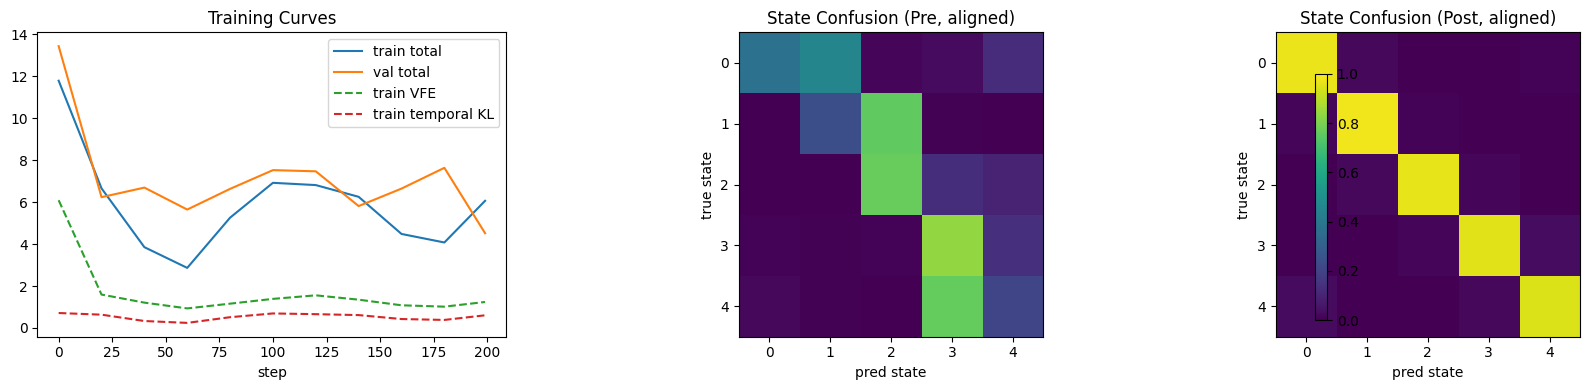

In [8]:
def confusion_matrix(true_states: jnp.ndarray, pred_states: jnp.ndarray, num_states: int):
    cm = jnp.zeros((num_states, num_states))
    t = true_states.reshape(-1)
    p = pred_states.reshape(-1)
    cm = cm.at[t, p].add(1)
    cm = cm / jnp.clip(cm.sum(axis=1, keepdims=True), a_min=1.0)
    return cm


val_batch_full = val_data
val_agent_full = build_agent(val_batch_full['x_seq'].shape[0])

pre_metrics = evaluate_model(model_init, val_batch_full, val_agent_full)
post_metrics = evaluate_model(model, val_batch_full, val_agent_full)

# Encoder-level discrete category assignment quality
flat_x = val_data['x_seq'].reshape(-1, D)
flat_s = val_data['s_seq'].reshape(-1)

enc_pre = predict_obs_idx(model_init, flat_x)
enc_post = predict_obs_idx(model, flat_x)
enc_pre_aligned, enc_pre_perm = best_aligned_accuracy(flat_s, enc_pre)
enc_post_aligned, enc_post_perm = best_aligned_accuracy(flat_s, enc_post)

print('Encoder aligned acc (pre/post):', enc_pre_aligned, enc_post_aligned)
print('Inferred-state aligned acc (pre/post):', pre_metrics['aligned_acc'], post_metrics['aligned_acc'])

pre_pred_aligned = jnp.array(pre_metrics['best_perm'])[pre_metrics['pred_states']]
post_pred_aligned = jnp.array(post_metrics['best_perm'])[post_metrics['pred_states']]
cm_pre = confusion_matrix(val_data['s_seq'], pre_pred_aligned, K)
cm_post = confusion_matrix(val_data['s_seq'], post_pred_aligned, K)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(curve_steps, train_total_curve, label='train total')
axes[0].plot(curve_steps, val_total_curve, label='val total')
axes[0].plot(curve_steps, train_vfe_curve, '--', label='train VFE')
axes[0].plot(curve_steps, train_temp_curve, '--', label='train temporal KL')
axes[0].set_title('Training Curves')
axes[0].set_xlabel('step')
axes[0].legend()

axes[1].imshow(cm_pre, vmin=0.0, vmax=1.0)
axes[1].set_title('State Confusion (Pre, aligned)')
axes[1].set_xlabel('pred state')
axes[1].set_ylabel('true state')

im = axes[2].imshow(cm_post, vmin=0.0, vmax=1.0)
axes[2].set_title('State Confusion (Post, aligned)')
axes[2].set_xlabel('pred state')
axes[2].set_ylabel('true state')

fig.colorbar(im, ax=axes[1:3], shrink=0.8)
fig.tight_layout()
plt.show()

## 9. Plan from Continuous Observations

After training, we run a rollout starting from state 0.

At each step, the agent receives a continuous sample, maps it through the encoder, infers state beliefs, selects an action from policy inference, and transitions under fixed `B`.



In [9]:
def rollout_from_state_zero(model_eval: FrontendModel, horizon: int = ROLLOUT_HORIZON, seed: int = 1):
    agent = build_agent(batch_size=1)

    key = jr.PRNGKey(seed)
    s_t = START_STATE
    prior = [jax.nn.one_hot(jnp.array([s_t], dtype=jnp.int32), K)]

    states = [int(s_t)]
    actions = []
    obs_points = []
    obs_probs_hist = []
    qs_hist = []

    for _ in range(horizon):
        key, key_obs = jr.split(key)

        x_t = GAUSSIAN_MEANS[s_t] + GAUSSIAN_SCALE * jr.normal(key_obs, (D,))
        obs_t = model_obs_categorical(model_eval, x_t[None, :])

        qs_t_hist = agent.infer_states(obs_t, empirical_prior=prior)
        qs_t = qs_t_hist[0][:, -1, :][0]

        q_pi_t, _ = agent.infer_policies(qs_t_hist)
        a_t = agent.sample_action(q_pi_t)
        a_int = int(a_t[0, 0])

        next_probs = B_TRUE[:, s_t, a_int]
        s_next = int(jnp.argmax(next_probs))

        obs_points.append(x_t)
        obs_probs_hist.append(obs_t[0][0])
        qs_hist.append(qs_t)
        actions.append(a_int)
        states.append(s_next)

        prior = agent.update_empirical_prior(a_t, qs_t_hist)
        s_t = s_next

    return {
        'states': jnp.array(states),          # length horizon+1
        'actions': jnp.array(actions),        # length horizon
        'obs_points': jnp.stack(obs_points),  # (horizon, 2)
        'obs_probs': jnp.stack(obs_probs_hist),
        'qs': jnp.stack(qs_hist),
    }


rollout = rollout_from_state_zero(model, horizon=ROLLOUT_HORIZON, seed=1)
action_names = ['back', 'stay', 'forward']

print('rollout states:', rollout['states'].tolist())
print('rollout actions:', [action_names[int(a)] for a in rollout['actions']])
print('reached target:', int(rollout['states'][-1]) == TARGET_STATE)

/var/folders/_f/1qqqnkyd5k5g2b1pgfwzzrqm0000gn/T/ipykernel_5016/1731807479.py:39: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Agent(


rollout states: [0, 1, 2, 3, 4, 4, 4, 4, 4]
rollout actions: ['forward', 'forward', 'forward', 'forward', 'forward', 'forward', 'forward', 'forward']
reached target: True


## 10. Animation: Continuous Density + Inference During Control

The first GIF visualizes control over the continuous observation space:

- left panel: state geometry, trajectory, and sampled observations over a Gaussian-density background
- right panel: inferred state posterior `q(s_t)` over time
- title: current inference summary plus the action taken at the previous timestep



In [10]:
def gaussian_pdf_sum_grid(means: jnp.ndarray, sigma: float, x_min: float, x_max: float, y_min: float, y_max: float, n: int = 280):
    xs = jnp.linspace(x_min, x_max, n)
    ys = jnp.linspace(y_min, y_max, n)
    xx, yy = jnp.meshgrid(xs, ys)
    grid = jnp.stack([xx, yy], axis=-1)  # (n, n, 2)

    diffs = grid[:, :, None, :] - means[None, None, :, :]  # (n, n, K, 2)
    sq_maha = jnp.sum((diffs / sigma) ** 2, axis=-1)

    norm = 1.0 / (2.0 * jnp.pi * (sigma ** 2))
    pdf_each = norm * jnp.exp(-0.5 * sq_maha)
    pdf_sum = jnp.sum(pdf_each, axis=-1)  # (n, n)

    return pdf_sum, norm


def normalize_density_for_display(pdf_sum: jnp.ndarray, mode_peak: float):
    # Saturate at single-Gaussian mode height so each cluster center can reach max color.
    capped = jnp.minimum(pdf_sum, mode_peak)

    lo = jnp.min(capped)
    hi = jnp.max(capped)
    denom = jnp.maximum(hi - lo, 1e-12)

    return (capped - lo) / denom


def make_rollout_gif(rollout_data: dict):
    states = rollout_data['states']
    actions = rollout_data['actions']
    obs_points = rollout_data['obs_points']
    obs_probs = rollout_data['obs_probs']
    qs = rollout_data['qs']

    horizon = actions.shape[0]

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5))

    pad = 3 * GAUSSIAN_SCALE
    x_min = float(jnp.min(GAUSSIAN_MEANS[:, 0])) - pad
    x_max = float(jnp.max(GAUSSIAN_MEANS[:, 0])) + pad
    y_min = float(jnp.min(GAUSSIAN_MEANS[:, 1])) - pad
    y_max = float(jnp.max(GAUSSIAN_MEANS[:, 1])) + pad

    # Left: line-world geometry on top of summed Gaussian PDF background.
    region_cmap = plt.get_cmap('tab10', K)
    pdf_bg_sum, mode_peak = gaussian_pdf_sum_grid(GAUSSIAN_MEANS, GAUSSIAN_SCALE, x_min, x_max, y_min, y_max)
    pdf_bg = normalize_density_for_display(pdf_bg_sum, mode_peak)

    ax_l.imshow(
        pdf_bg,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='seismic',
        vmin=0.0,
        vmax=1.0,
        alpha=0.82,
        aspect='auto',
        zorder=0,
    )

    ax_l.plot(GAUSSIAN_MEANS[:, 0], GAUSSIAN_MEANS[:, 1], 'k--', alpha=0.35, linewidth=1.0, zorder=2)
    ax_l.scatter(GAUSSIAN_MEANS[:, 0], GAUSSIAN_MEANS[:, 1], s=180, c=jnp.arange(K), cmap=region_cmap, zorder=3, edgecolors='black')
    for s in range(K):
        ax_l.text(float(GAUSSIAN_MEANS[s, 0]) + 0.08, float(GAUSSIAN_MEANS[s, 1]) + 0.08, f's{s}', fontsize=10)

    path_line, = ax_l.plot([], [], '-o', color='tab:red', linewidth=2.0, markersize=6, zorder=4)
    obs_dot = ax_l.scatter([], [], s=112, marker='x', color='green', linewidths=2.0, zorder=5)

    ax_l.set_title('State Path over Continuous Observation Density')
    ax_l.set_xlabel('x1')
    ax_l.set_ylabel('x2')
    ax_l.set_aspect('equal', adjustable='box')
    ax_l.set_xlim(x_min, x_max)
    ax_l.set_ylim(y_min, y_max)

    # Right: inferred state posterior q(s_t) over time.
    heat_init = jnp.full((K, horizon), jnp.nan)
    heat = ax_r.imshow(heat_init, vmin=0.0, vmax=1.0, cmap='viridis', origin='lower', aspect='auto')
    ax_r.set_title('Inference Result: q(s_t)')
    ax_r.set_xlabel('timestep')
    ax_r.set_ylabel('state index')
    ax_r.set_xticks(range(horizon))
    ax_r.set_yticks(range(K))
    fig.colorbar(heat, ax=ax_r, fraction=0.046, pad=0.04)

    title = fig.suptitle('', fontsize=12)

    def update(frame):
        # Show states only up to current time t (edge for a_t appears at frame t+1).
        state_path = states[: frame + 1]
        coords = GAUSSIAN_MEANS[state_path]
        path_line.set_data(coords[:, 0], coords[:, 1])

        # Continuous observation sampled at current timestep t.
        obs_dot.set_offsets(obs_points[: frame + 1])

        # Show inference results up to current frame.
        heat_arr = jnp.full((K, horizon), jnp.nan)
        heat_arr = heat_arr.at[:, : frame + 1].set(jnp.stack(qs[: frame + 1], axis=1))
        heat.set_data(heat_arr)

        enc_idx = int(jnp.argmax(obs_probs[frame]))
        q_idx = int(jnp.argmax(qs[frame]))
        action_taken = 'None' if frame == 0 else action_names[int(actions[frame - 1])]

        title.set_text(
            f't={frame} | true_state={int(states[frame])} | encoded_obs_idx={enc_idx} | inferred_state={q_idx} | action taken: {action_taken}'
        )

        return path_line, obs_dot, heat

    ani = animation.FuncAnimation(fig, update, frames=horizon, interval=900, blit=False, repeat=True)
    plt.close(fig)
    return ani


make_rollout_gif_anim = make_rollout_gif(rollout)
make_rollout_gif_anim



## 11. Animation: Encoder Decision Regions + Control Trajectory

The second GIF replaces the left-panel density background with encoder decision regions.

Each region corresponds to the observation index predicted by the encoder, making the learned continuous-to-discrete partition explicit during rollout.



In [11]:
def encoder_decision_grid(model_eval: FrontendModel, x_min: float, x_max: float, y_min: float, y_max: float, n: int = 320):
    xs = jnp.linspace(x_min, x_max, n)
    ys = jnp.linspace(y_min, y_max, n)
    xx, yy = jnp.meshgrid(xs, ys)

    pts = jnp.stack([xx.reshape(-1), yy.reshape(-1)], axis=-1)
    pred = predict_obs_idx(model_eval, pts).reshape(n, n)

    return xx, yy, pred


def make_rollout_decision_gif(model_eval: FrontendModel, rollout_data: dict):
    states = rollout_data['states']
    actions = rollout_data['actions']
    obs_points = rollout_data['obs_points']
    obs_probs = rollout_data['obs_probs']
    qs = rollout_data['qs']

    horizon = actions.shape[0]

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5))

    pad = 3 * GAUSSIAN_SCALE
    x_min = float(jnp.min(GAUSSIAN_MEANS[:, 0])) - pad
    x_max = float(jnp.max(GAUSSIAN_MEANS[:, 0])) + pad
    y_min = float(jnp.min(GAUSSIAN_MEANS[:, 1])) - pad
    y_max = float(jnp.max(GAUSSIAN_MEANS[:, 1])) + pad

    xx, yy, pred_grid = encoder_decision_grid(model_eval, x_min, x_max, y_min, y_max, n=320)

    region_cmap = plt.get_cmap('tab10', K)
    region_img = ax_l.imshow(
        pred_grid,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap=region_cmap,
        vmin=-0.5,
        vmax=K - 0.5,
        interpolation='nearest',
        alpha=0.72,
        aspect='auto',
        zorder=0,
    )

    ax_l.contour(
        xx,
        yy,
        pred_grid,
        levels=jnp.arange(0.5, K, 1.0),
        colors='white',
        linewidths=0.8,
        alpha=0.9,
        zorder=1,
    )

    ax_l.plot(GAUSSIAN_MEANS[:, 0], GAUSSIAN_MEANS[:, 1], 'k--', alpha=0.35, linewidth=1.0, zorder=2)
    ax_l.scatter(GAUSSIAN_MEANS[:, 0], GAUSSIAN_MEANS[:, 1], s=180, c=jnp.arange(K), cmap=region_cmap, zorder=3, edgecolors='black')
    for s in range(K):
        ax_l.text(float(GAUSSIAN_MEANS[s, 0]) + 0.08, float(GAUSSIAN_MEANS[s, 1]) + 0.08, f's{s}', fontsize=10)

    path_line, = ax_l.plot([], [], '-o', color='tab:red', linewidth=2.0, markersize=6, zorder=4)
    obs_dot = ax_l.scatter([], [], s=112, marker='x', color='black', linewidths=2.0, zorder=5)

    ax_l.set_title('State Path over Encoder Decision Regions')
    ax_l.set_xlabel('x1')
    ax_l.set_ylabel('x2')
    ax_l.set_aspect('equal', adjustable='box')
    ax_l.set_xlim(x_min, x_max)
    ax_l.set_ylim(y_min, y_max)

    cb_left = fig.colorbar(region_img, ax=ax_l, fraction=0.046, pad=0.03, ticks=jnp.arange(K))
    cb_left.set_label('encoder class')

    heat_init = jnp.full((K, horizon), jnp.nan)
    heat = ax_r.imshow(heat_init, vmin=0.0, vmax=1.0, cmap='viridis', origin='lower', aspect='auto')
    ax_r.set_title('Inference Result: q(s_t)')
    ax_r.set_xlabel('timestep')
    ax_r.set_ylabel('state index')
    ax_r.set_xticks(range(horizon))
    ax_r.set_yticks(range(K))
    fig.colorbar(heat, ax=ax_r, fraction=0.046, pad=0.04)

    title = fig.suptitle('', fontsize=12)

    def update(frame):
        state_path = states[: frame + 1]
        coords = GAUSSIAN_MEANS[state_path]
        path_line.set_data(coords[:, 0], coords[:, 1])

        obs_dot.set_offsets(obs_points[: frame + 1])

        heat_arr = jnp.full((K, horizon), jnp.nan)
        heat_arr = heat_arr.at[:, : frame + 1].set(jnp.stack(qs[: frame + 1], axis=1))
        heat.set_data(heat_arr)

        enc_idx = int(jnp.argmax(obs_probs[frame]))
        q_idx = int(jnp.argmax(qs[frame]))
        action_taken = 'None' if frame == 0 else action_names[int(actions[frame - 1])]

        title.set_text(
            f't={frame} | true_state={int(states[frame])} | encoded_obs_idx={enc_idx} | inferred_state={q_idx} | action taken: {action_taken}'
        )

        return path_line, obs_dot, heat

    ani = animation.FuncAnimation(fig, update, frames=horizon, interval=900, blit=False, repeat=True)
    plt.close(fig)
    return ani


make_rollout_decision_gif_anim = make_rollout_decision_gif(model, rollout)
make_rollout_decision_gif_anim



## 12. Summary

This notebook demonstrates a practical recipe for combining a differentiable layer with an structured `pymdp` generative model that can be trained with gradients & backpropagation, while the active inference agent performs variational inference and planning with explicit active inference style updates.

One way of interpreting the differentiable front-end in this notebook, is as an _amortized inference module_ that learns how to execute inference in a Gaussian mixture model in its forward pass; specifically computing the latent assignment variable of a GMM (also known as the "E-step"). The analogy to amortized inference is not exact since the MLP layer is not guaranteed to provide calibrated probabilistic assignments; the decision-boundaries it creates in 2-D space are not the same as the soft decision-boundaries achieved by fitting a proper GMM via expectation maximization or variational Bayesian expectation maximization.

In the current notebook, we fixed the generative model at the `pymdp` level; a natural next step would be to combine gradient-based learning with either gradient-based or explicitly Bayesian updates to the POMDP model parameters (A, B, and D).